In [1]:
# 1. Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
# Visual configuration for plots
sns.set_theme(style="whitegrid")

In [3]:
# 2. Loading the data
# Using the output from your clustering notebook
df = pd.read_csv('../WDI-2022-clustering/WDI2022_clusters.csv')

# Rename the cluster column name
df.rename(columns={'Cluster_KMeans': 'Cluster'}, inplace=True)

# The target variable is the 'Cluster' column
target_col = 'Cluster'

# Removing rows where the target might be empty (just a safety check)
df = df.dropna(subset=[target_col])

In [4]:
df.columns

Index(['Country Name', 'Country Code', 'Region',
       'corruption_perception_estimate', 'access_to_electricity_percent',
       'co2_emissions_per_capita',
       'mobile_cellular_subscriptions_per_100_people',
       'agriculture_value_added_percent_gdp',
       'industry_value_added_percent_gdp', 'gdp_growth_annual_percent',
       'gdp_per_capita_usd', 'stability_of_government_estimate',
       'health_expenditure_pct_gdp', 'child_mortality_rate',
       'life_expectancy_at_birth', 'fertility_rate_total',
       'population_65_plus_percent', 'population_total',
       'urban_population_percent', 'Cluster', 'Cluster_HDBSCAN'],
      dtype='object')

In [5]:
# 3. Separating the predictor variables (X) and the target variable (y)
cols_to_drop = ['Country Name', 'Country Code', 'Region', 'child_mortality_rate', 
                'Cluster_HDBSCAN', target_col] 
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df[target_col]

In [6]:
# 4. Splitting into Train (80%) and Test (20%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# 5. Training the Classification Model
print("Training the Random Forest Classifier model...")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

Training the Random Forest Classifier model...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
# 6. Making predictions on test data
y_pred = rf_classifier.predict(X_test)

In [9]:
# 7. Evaluating the Model
accuracy = accuracy_score(y_test, y_pred)

print("\n--- Evaluation Metrics ---")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}% of countries correctly classified)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Evaluation Metrics ---
Accuracy: 0.9545 (95.45% of countries correctly classified)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.95      0.95      0.95        19
           2       1.00      1.00      1.00        15

    accuracy                           0.95        44
   macro avg       0.95      0.95      0.95        44
weighted avg       0.95      0.95      0.95        44



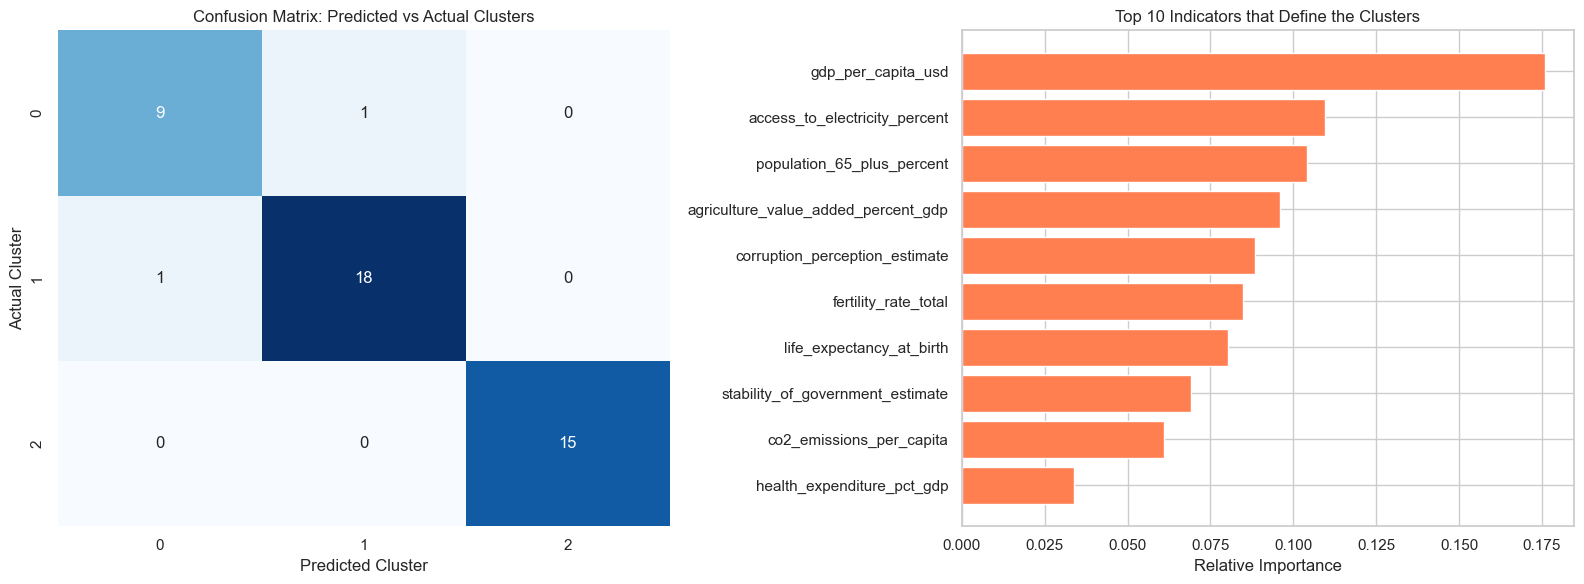

In [10]:
# ==========================================
# SOME PLOTS TO VISUALIZE THE RESULTS
# ==========================================

plt.figure(figsize=(16, 6))

# Plot 1: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Predicted vs Actual Clusters')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')

# Plot 2: Feature Importance
plt.subplot(1, 2, 2)
importances = rf_classifier.feature_importances_
# Getting the top 10 most important indicators
indices = np.argsort(importances)[-10:] 
features = X.columns

plt.barh(range(len(indices)), importances[indices], color='coral', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Top 10 Indicators that Define the Clusters')
plt.xlabel('Relative Importance')

plt.tight_layout()
plt.show()